# Module 2: Epidemic Modeling

## Team Members: Will Marschall and Reagan Oswald

## Project Title: Mystery Virus Outbreak Modeling

## Project Goal: This project seeks to use sequential outbreak data releases to estimate how quickly a mystery virus spreads, fit an SEIR epidemic model to observed infection data, evaluate how well that model predicts future outbreak behavior, and recommend interventions for reducing spread in a new university population.

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis

### 2a. Methods

#### Data Release 1 (Initial Estimates and Approximations)

We loaded the Data Release #1 CSV containing day number and active reported daily cases, and plotted **day vs. active infections**.

To estimate early spread speed, we used the Day 2 approach that early epidemic growth can be approximated as continuous exponential growth, $(I(t) = I_0 e^{rt})$, where $(r)$ is estimated by fitting an exponential curve to early infection data.


We then estimated $(R_0)$ using the Day 2 approximation $R_0 \approx e^{rD}$, where $(D)$ is the infectious period. For $(D)$, we used the “New information about our mystery virus” statement that the symptomatic period is 5–9 days and individuals are infectious for 2 days before symptoms appear, giving $(D \approx [7, 11])$ days.

Finally, we used the provided `viruses.html` visualization to identify diseases with similar $R_0$ and compare approximate transmissibility and case fatality rate (CFR).

#### Data Release 2 (SEIR modeling + parameter fitting)

For Data Release #2, we modeled the outbreak using an **SEIR compartment model** and solved the system numerically with **Euler’s method**. Euler’s method uses the update rule $y_{i+1}=y_i+f(t_i,y_i)h$. We used the SEIR differential equations shown in class:
$\frac{dS}{dt}=-\beta \frac{SI}{N}$,
$\frac{dE}{dt}=\beta \frac{SI}{N}-\sigma E$,
$\frac{dI}{dt}=\sigma E-\gamma I$,
$\frac{dR}{dt}=\gamma I$

We then fit parameters $\beta$ (transmission), $\sigma$ (incubation/latency rate), and $\gamma$ (recovery rate) by performing a 3-parameter grid search that minimizes the objective function
$\mathrm{SSE}=\sum (I_{\mathrm{obs}}-I_{\mathrm{model}})^2$
We used the parameter ranges and resolution specified in `seir_grid_search.html`: $\beta \in [0.3,0.7]$, $\sigma \in [0.1,0.3]$, $\gamma \in [0.05,0.25]$ with 15 points per parameter.

Finally, we computed an implied basic reproduction number using the relationship $R_0=\beta/\gamma$ and predicted the peak by running the best-fit model forward in time and finding the maximum of $I(t)$.

**Modeling assumption:** We set $N=10{,}000$ to match the example population size used in class. If a different population size is wanted for the mystery outbreak, we can update $N$ accordingly.

#### Data Release 3 (model validation + intervention analysis)
For our Data Release #3, we used the best-fit SEIR parameters from the Data Release #2 and compared that model to the full 120-day outbreak dataset. We again solved the SEIR system with Euler's method using the update rule $y_{i+1}=y_i+f(t_i,y_i)h$ and plotted model-predicted active infections $I(t)$ against the observed active infection counts from Release #3.

To evaluate prediction accuracy, we compared the model prediction to the full Data Release #3 infection counts and evaluated using the definitions of true error $E_t ​= true value − approximation$ and true percent relative error $ \%e_t ​= (true value−approximation) / true value ​× 100\% $.

Second, we used the same fitted SEIR parameters to model intervention strategies for a new outbreak at Virginia Tech (VT), following the setup explained during class. We used VT's student population as the susceptible pool, with initial conditions: $ S_0 = N - E_0 - I_0 - R_0 $, where $ N = 38,294$, $I_0 = 1$, $R_0 = 0$, and $E_0(VT) = E_0(UVA)$. We simulated a baseline no-intervention scenario through day 120, then applied three interventions beginning at day 70: a masking mandate that reduced transmission by 40%, a single vaccine campaign moving $2000 * 0.9$ individuals from $S$ to $R$ at day 70, and a vaccine rollout moving $1000 * 0.9$ individuals from $S$ to $R$ at days 70, 80, and 90. We compared interventions to baseline using both peak infections and the summed active infections over days 70–120 as a simple burden metric.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)

### **Day 1 - Part 2B**

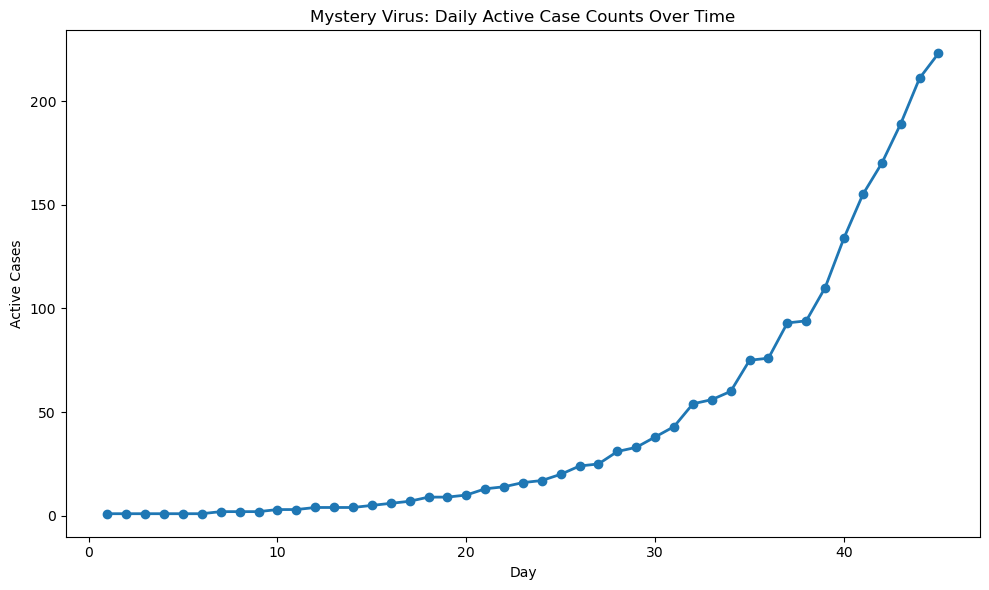

In [15]:
# This allows us to view the plots/outputs inline isntead of having pages and pages of code
# If you would like to see the full code/comments, go under the 'Code' folder and open the .py files, making sure to change the file paths
from IPython.display import display, Markdown

def step(title: str):
    display(Markdown(f"### **{title}**"))

step("Day 1 - Part 2B")
import main
main.exploratory_analysis_day1_2b()

**What do you notice about the initial infections?**

Initially in the earlier days the infection has spead to few people. But the number of active cases increases exponentially because when more people are infected, they can spread the  infecton much more quickly

**How could we measure how quickly its spreading?**

By finding the rate of change of the graph we can measure how quickly the infection spreads as a rate across days. 

**What information about the virus would be helpful in determining the shape of the outbreak curve?**

It would be helpful to know how the virus spreads. Viruses that spread more easily will likely have a greater rate of  infection and result in a greater outbreak curve. For example, an airborne virus may infect a population faster than one that spreads fluids

### **Day 2 - Part 2B**

Fit window: day >= 10
Estimated exponential growth rate r: 0.1197 per day
Estimated R0 range using D in [7.0, 11.0] days:
  R0_min (D=7.0) = 2.312
  R0_mid (D=9.0) = 2.937
  R0_max (D=11.0) = 3.732


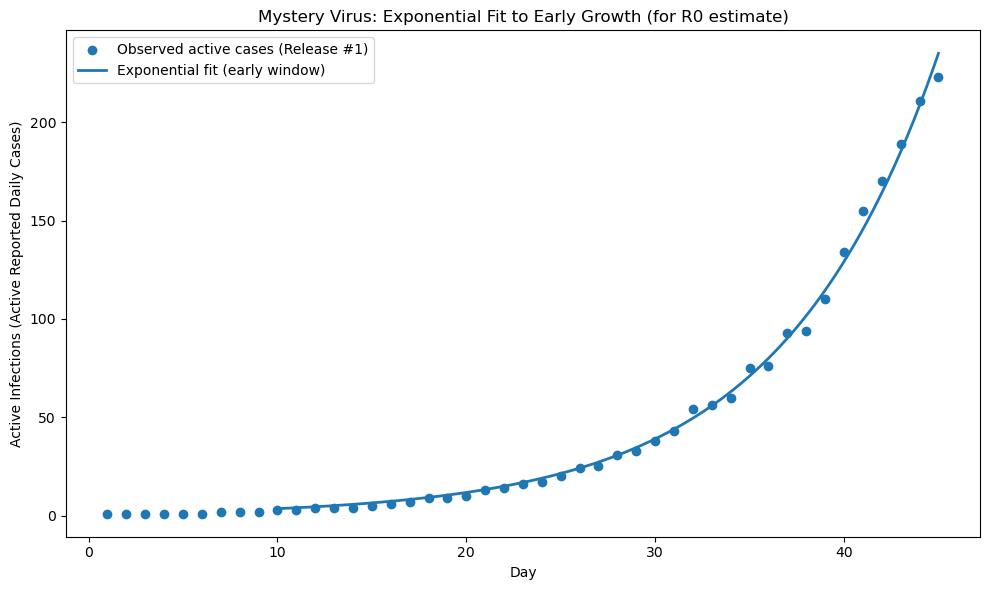

In [3]:
step("Day 2 - Part 2B")
main.exploratory_analysis_day2_2b()

**What viruses have a similar R0? Use the viruses.html file to find a virus or 2 with a similar R0 and give a 1-2 sentence background of the diseases.**

COVID-19 (Original) was found to be near my $R_0$ (2.937). It reported to have a $R_0$ of 3 and $CFR = 1%$, and it is marked under the "Vaccine Available" category. COVID-19 is has an ~5-day incubation period and it can be infectious ~2 days before symptoms.

Zika was found to be near my $R_0$ (2.937). It reported to have a $R_0$ of 3 and $CFR = 0.02%$, and it is marked under the "No Vaccine" category. Zika virus is a mosquito-borne pathogen that gained global attention during a 2015 outbreak.

**How accurate do you think your R0 estimate is?**

My $R_0$ is reasonable but approximate, because we explicitly treat this as an early-epidemic approximation based on fitting exponential growth and then converting. The biggest uncertainty is $D$ (infectious period) as we only have limited timing information (symptomatic period 5-9 days). Also the fitted growth rate $r$ can change depending on which days we treat as the "early exponential window" (we chose day >= 10, and viruses.html notes that $R_0$ estimates vary with behavior and population density).


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.

### **Day 3 - Part 2C**

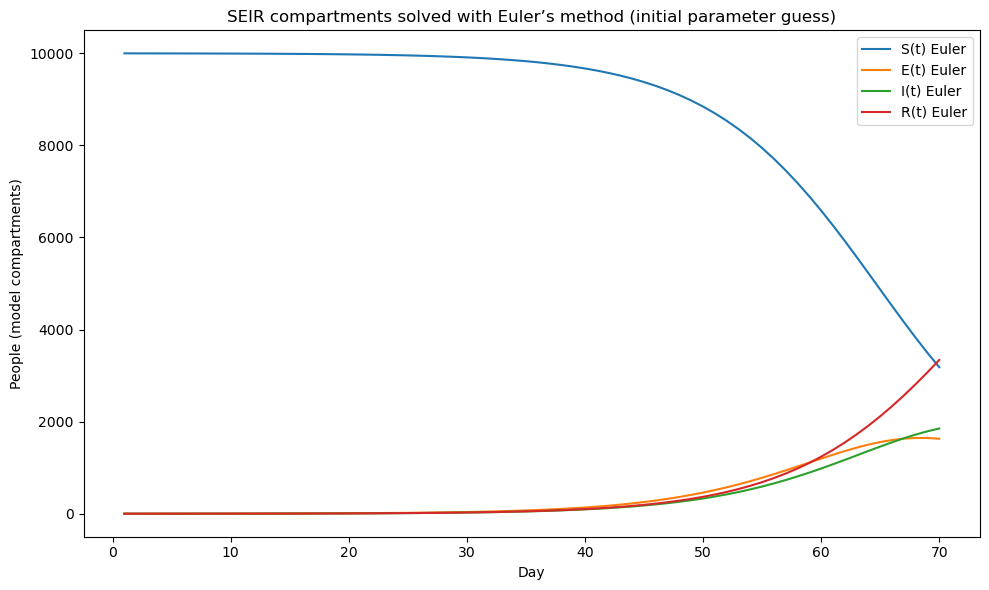

In [4]:
step("Day 3 - Part 2C")
main.exploratory_analysis_day3_2c()

We solved the SEIR system using Euler’s method, applying the update rule $y_{i+1}=y_i+f(t_i,y_i)h$.

Using an initial parameter guess within the grid-search ranges $\beta=0.5,\sigma=0.2,\gamma=0.15$; chosen as mid-range values from `seir_grid_search.html`, the Euler solution produced the expected qualitative compartment behavior: $S(t)$ decreases while $E(t),I(t),R(t)$ increase over the observed 70 days. This confirmed to us that our Euler implementation is correctly propagating the SEIR dynamics described in the equations we talked about in class.

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.

In [18]:
step("Day 3 - Part 2D")
main.exploratory_analysis_day3_2d()

### **Day 3 - Part 2D**

Best-fit parameters from 3-parameter grid search (min SSE):
  beta  = 0.586
  sigma = 0.114
  gamma = 0.107
  SSE   = 98824.33
  Implied R0 (R0 = beta/gamma) = 5.467


We first fitted $\beta,\sigma,\gamma$ using a 3-parameter grid search that minimizes
$\mathrm{SSE}=\sum (I_{\mathrm{obs}}-I_{\mathrm{model}})^2$. We used the ranges/resolution from `seir_grid_search.html`:
$\beta \in [0.3,0.7]$, $\sigma \in [0.1,0.3]$, $\gamma \in [0.05,0.25]$ with 15 points per parameter.

Best-fit results (minimum SSE):

- $\beta = 0.586$

- $\sigma = 0.114$

- $\gamma = 0.107$

- $\mathrm{SSE} = 98{,}824.33$

Using the relationship $R_0=\beta/\gamma$, the implied
$R_0 \approx 0.586/0.107 \approx 5.467$.

Interpreting $\sigma$ and $\gamma$ using definitions ($\sigma=1/\text{latent period}$, $\gamma=1/\text{infectious period}$:

- Latent period $\approx 1/\sigma \approx 1/0.114 \approx 8.8$ days

- Infectious period $\approx 1/\gamma \approx 1/0.107 \approx 9.3$ days

### 2e. Plot the model-predicted infections over time compared to the data.

### **Day 3 - Part 2E**

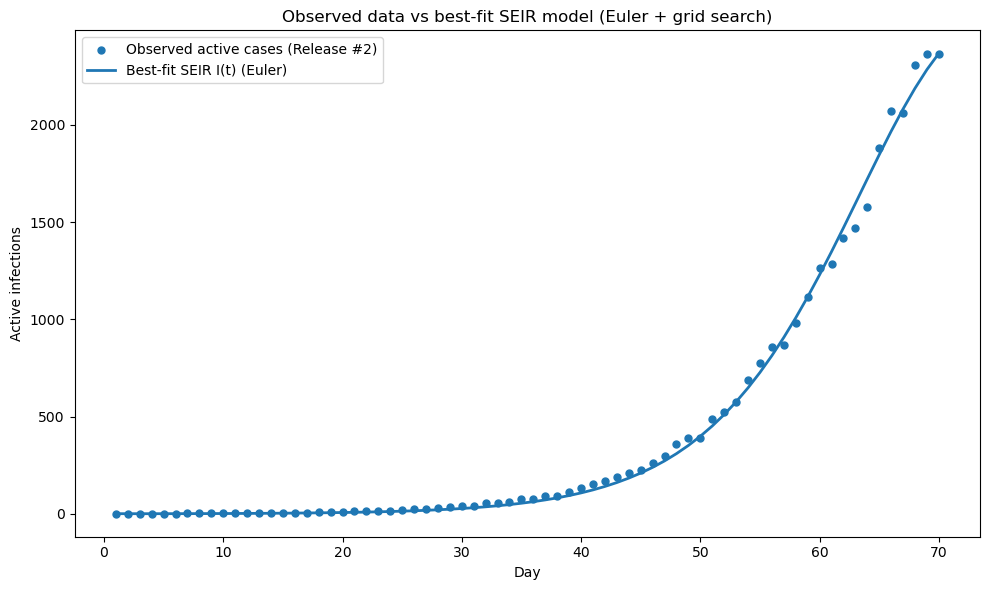

In [6]:
step("Day 3 - Part 2E")
main.exploratory_analysis_day3_2e()

Using the best-fit parameters from 2d, we solved the SEIR model again with Euler’s method and plotted the model-predicted $I(t)$ against the observed active infection counts from Data Release #2.

In a visual sense, the best-fit SEIR curve closely tracks the observed data through the rapid growth phase and remains near the final observed values (e.g., the dataset reaches 2,363 active cases at day 70). This indicates the chosen $\beta,\sigma,\gamma$ minimize SSE over the full 70-day dataset under the grid-search procedure.

### 2f. Predict the day and amount of active cases at the peak of the epidemic spread.

### **Day 3 - Part 2F**


Peak prediction from best-fit model (running forward):
  Peak day (model)        = 75
  Peak active infections  = 2556.4


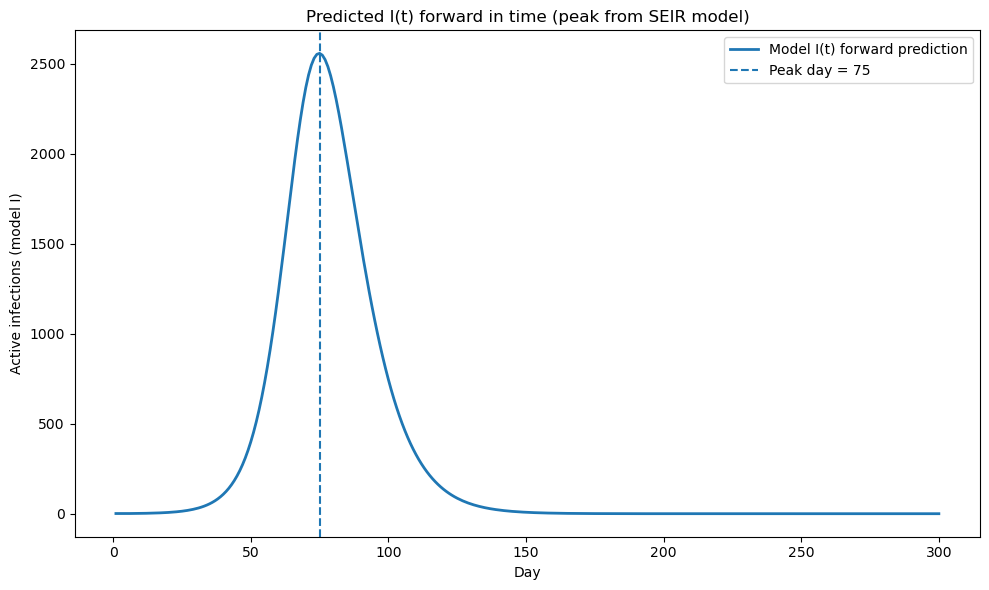

In [7]:
step("Day 3 - Part 2F")
main.exploratory_analysis_day3_2f()

We saw how lecture 3 describes predicting the peak by running the best-fit model forward in time and finding when $I(t)$ reaches its maximum. Using our best-fit $\beta,\sigma,\gamma$, we ran the Euler SEIR simulation forward to day 300 and located the maximum of $I(t)$.

Peak prediction (model):

- Predicted peak day = 75

- Predicted peak active infections = 2,556.4

Because the observed dataset ends at day 70 with 2,363 active infections, the model predicts the peak occurs about 5 days after the last observation and rises by about 193.4 active cases beyond the day-70 observed value.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2g. Plot the full dataset (Data Release #3) against your model.


### **Day 4 - Part 2g**


Release #3 vs model (fit from Release #2): Peak error metrics
True peak:   day 83, I = 3294.0
Model peak:  day 75, I = 2556.4
Et (peak I) = 737.6, %et = 22.39%
Et (peak day) = 8.0, %et = 9.64%


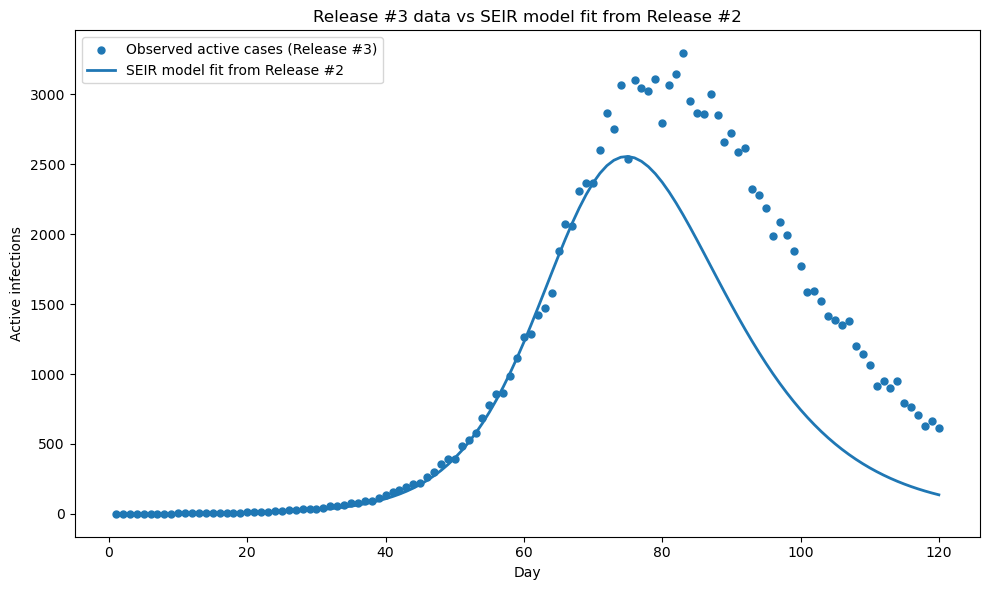

In [13]:
step("Day 4 - Part 2g")
main.exploratory_analysis_day4_2g()

Using the best-fit SEIR parameters from Data Release #2, we ran the model forward and compared it to the full observed Data Release #3 dataset. This served as a validation step, since the model was not re-fit to the new data. The observed epidemic peak in Data Release #3 occurred at day **83** with **3294.0** active infections, while the model predicted a peak at day **75** with **2556.4** active infections.

Using error definitions,

$$
E_t = \text{true value} - \text{approximation},
$$

the error in peak active infections was

$$
E_t = 3294.0 - 2556.4 = 737.6,
$$

with percent relative error

$$
\%e_t = \frac{737.6}{3294.0}\times 100\% \approx 22.39\%.
$$

For peak day, the error was

$$
E_t = 83 - 75 = 8 \text{ days},
$$

with percent relative error

$$
\%e_t = \frac{8}{83}\times 100\% \approx 9.64\%.
$$

Overall, the model captured the general epidemic timing and shape reasonably well, but it **underestimated the true peak size** and predicted the peak **too early**. This suggests that while the Release #2 SEIR fit was useful for forecasting general behavior, it did not fully capture the later outbreak dynamics seen in the full 120-day dataset.


### 2h. Intervention strategies for new outbreak at VT (70 days of infection)



### **Day 4 - Part 2h**


VT intervention comparison: peak metrics
Baseline: peak day 85, peak I 9784.6
Mask:     peak day 85, peak I 7980.3
Vax once: peak day 84, peak I 9211.9
Vax roll: peak day 84, peak I 9428.0

Sum of active infections over days 70–120 (burden proxy)
Baseline: 303743.1
Mask:     283287.8  (reduction 20455.2)
Vax once: 287292.3 (reduction 16450.8)
Vax roll: 282716.0 (reduction 21027.0)


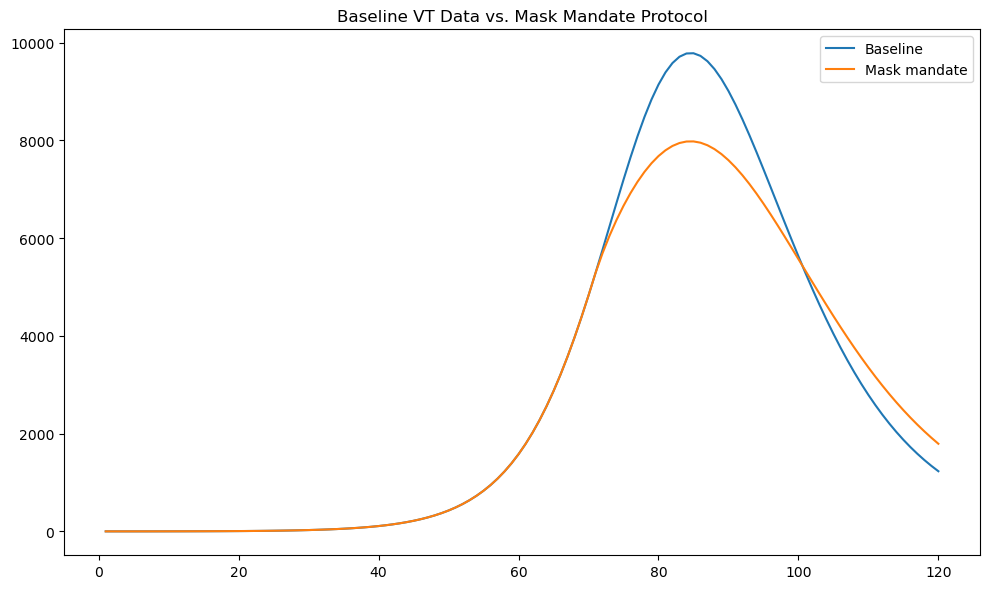

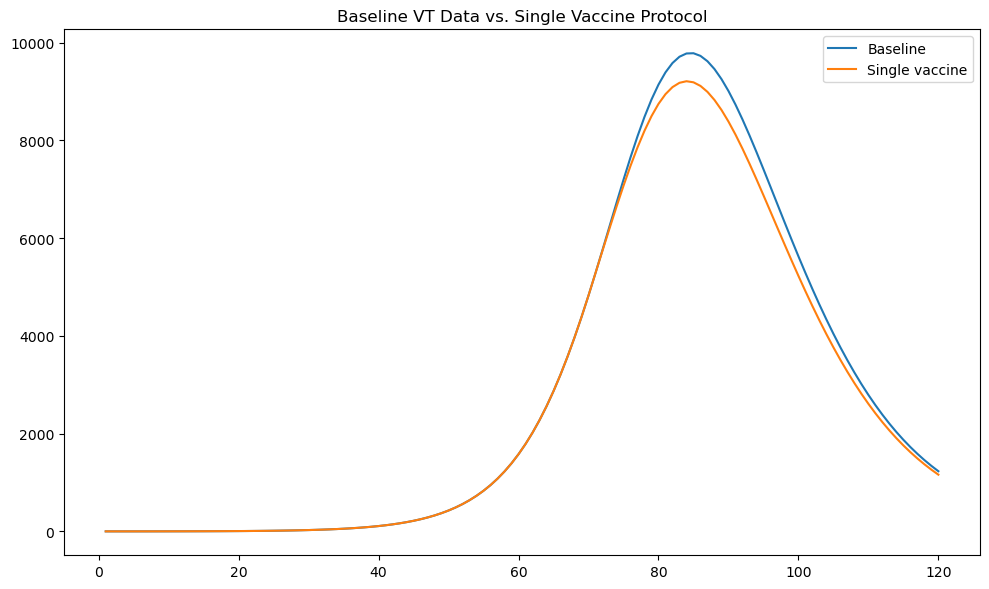

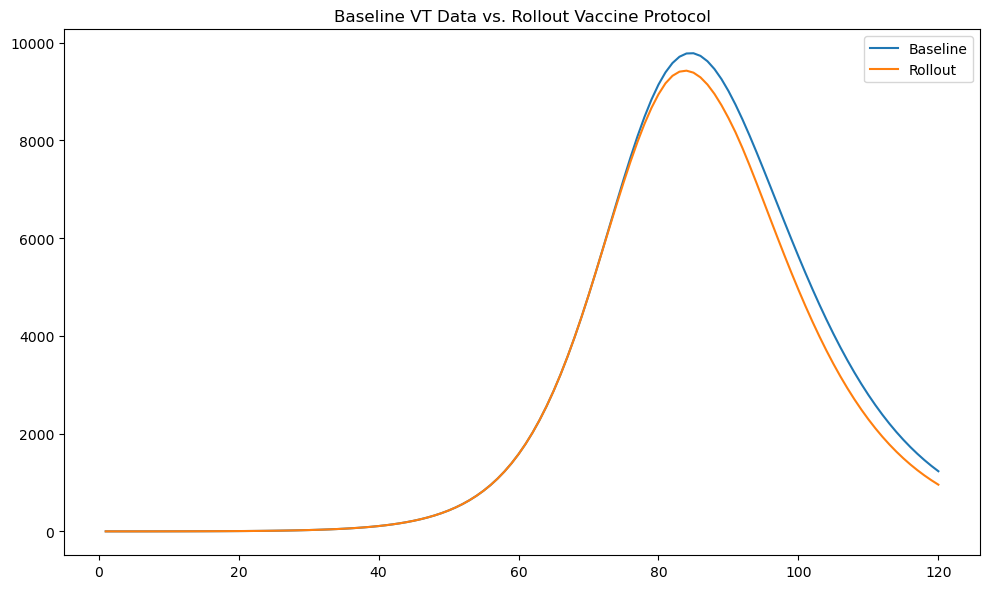

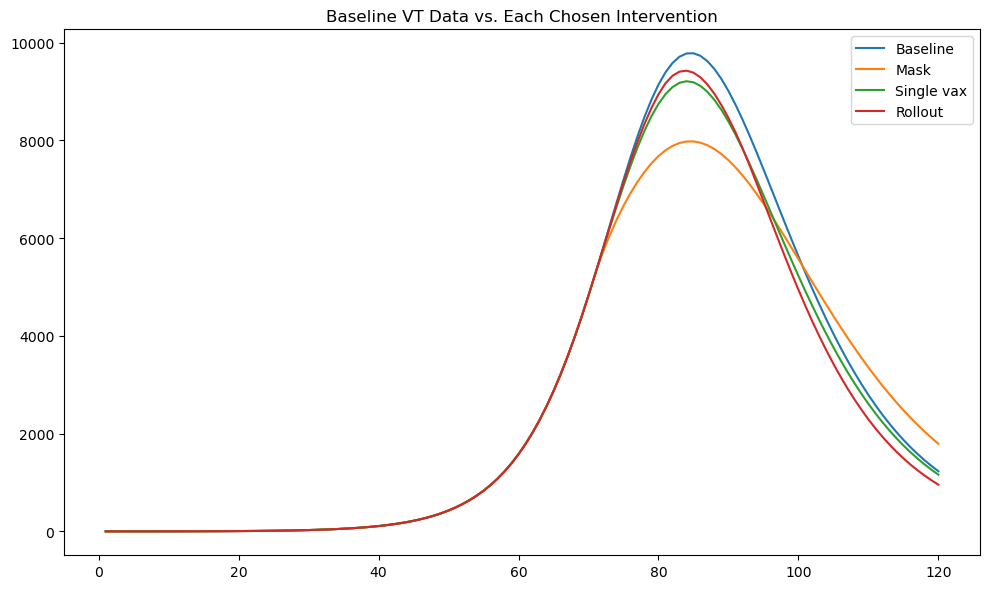

In [17]:
step("Day 4 - Part 2h")
main.exploratory_analysis_day4_2h()

Here, we used the best-fit SEIR parameters from Data Release #2, we modeled a new outbreak at VT and compared a baseline no-intervention case to three interventions beginning at day 70: masking, a one-time vaccine campaign, and a staged vaccine rollout. The baseline scenario produced a peak of **9784.6** active infections at day **85**.

The masking intervention reduced the peak to **7980.3** active infections at day **85**, corresponding to a reduction of

$$
9784.6 - 7980.3 = 1804.3
$$

active infections at peak. The one-time vaccine campaign reduced the peak to **9211.9** at day **84**, a reduction of

$$
9784.6 - 9211.9 = 572.7.
$$

The vaccine rollout reduced the peak to **9428.0** at day **84**, a reduction of

$$
9784.6 - 9428.0 = 356.6.
$$

We also compared the summed active infections over days 70–120 as a simple measure of total epidemic burden during the intervention period. The baseline burden was **303743.1**, while masking reduced this to **283287.8**, a reduction of **20455.2**. The one-time vaccine campaign reduced the burden to **287292.3**, a reduction of **16450.8**. The vaccine rollout reduced the burden to **282716.0**, a reduction of **21027.0**.

These results suggest that the **masking mandate** was most effective at reducing the **peak number of infections**, while the **vaccine rollout** gave the largest reduction in the **total burden over days 70–120**. Since masking produced the greatest peak reduction and rollout vaccination produced the greatest cumulative reduction, both appear beneficial.

## Verify and validate your analysis: 

### Verification:

We verified our code by checking that the Euler SEIR solver produced the expected compartment behavior: $S(t)$ decreased over time, while $E(t)$, $I(t)$, and $R(t)$ changed in biologically reasonable ways.

We also verified that our parameter fitting improved the model by using grid search to minimize

$$
\mathrm{SSE}=\sum\left(I_{\mathrm{obs}}-I_{\mathrm{model}}\right)^2.
$$

Our modeling process also matched the data available at each stage: Data Release #1 was used for an early exponential-growth estimate of $R_0$, Data Release #2 was used to fit the full SEIR model, and Data Release #3 was used to test that fitted model against new data and to run intervention scenarios.


### Validation:

We validated the model by comparing the Release #2 SEIR fit to the full Release #3 dataset. The true peak was day **83** with **3294.0** active infections, while the model predicted day **75** with **2556.4** active infections.

Using

$$
E_t = \text{true value} - \text{approximation},
$$

the peak-size error was **737.6** infections, with

$$
\%e_t \approx 22.39\%.
$$

The peak-day error was **8 days**, with

$$
\%e_t \approx 9.64\%.
$$

These results suggest that the model captured the general outbreak trend reasonably well, but it underestimated the true peak and predicted it too early.

### Potential Sources of Error and Limitations of Our Approach:

Our early $R_0$ estimate from exponential growth (**2.937**) was based on incomplete data, so it was more uncertain than the later SEIR-based estimate,
$$
R_0=\frac{\beta}{\gamma}\approx \frac{0.586}{0.107}\approx 5.467.
$$

The model also assumes homogeneous mixing, fixed parameters before intervention, and a fixed population size, which likely oversimplify real outbreak behavior.

Because Euler’s method is a numerical approximation, some error may also come from step size and truncation error, in addition to model error and noisy data.




## Conclusions and Ethical Implications: 

### Analysis Conclusions:

Our results suggest that the mystery virus is fairly transmissible. The early exponential estimate gave $R_0 \approx 2.937$, while the best-fit SEIR model gave

$$
R_0 \approx 5.467.
$$

Although these are not identical, both indicate meaningful spread in a university population.

The best-fit SEIR parameters gave a latent period of about

$$
\frac{1}{\sigma}\approx \frac{1}{0.114}\approx 8.8 \text{ days}
$$

and an infectious period of about

$$
\frac{1}{\gamma}\approx \frac{1}{0.107}\approx 9.3 \text{ days},
$$

which are biologically plausible. Using `viruses.html`, viruses with $R_0$ closest to ~5.5 include polio ($R_0 = 5.5$) and smallpox (families *Picornaviridae* and *Poxviridae*). Given the symptomatic/infectious timeline, we hypothesize the mystery virus is most consistent with the *Picornaviridae* family.

For the VT intervention analysis, all three interventions improved outcomes compared with baseline. Masking produced the largest reduction in the epidemic peak:

$$
9784.6 - 7980.3 = 1804.3,
$$

while the vaccine rollout produced the largest reduction in total burden over days 70–120:

$$
303743.1 - 282716.0 = 21027.0.
$$

Based on these results, we would recommend the **masking mandate** as the strongest single intervention if the priority is lowering the maximum number of simultaneous infections. If the goal is lowering total burden over time, the staged vaccine rollout also performed very well.


### Ethical Implications:

These model results should not be treated as exact forecasts. Our validation results showed that the model underestimated the true peak and predicted it too early, so any policy recommendation should be communicated with uncertainty.

Interventions also have unequal burdens. Masking is relatively low-cost, but compliance may vary and some groups may face more difficulty with prolonged masking. Vaccine-based strategies may reduce burden, but they depend on equitable access, trust, and participation.

Our model assumes that all individuals mix similarly and have similar risk, which is not true in real campus populations. Because of that, recommendations should be used as general guidance rather than as perfectly precise policy instructions for every subgroup.


## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## **Notes:** 

* **Completed:**

    * Data and Disease Background: Reagan

    * Data Analysis: Will and Reagan

    * Verification/Validation: Will
    
    * Conclusions/Ethics: Will

    * Limitations/Future Work: Reagan

* **To Do:**

    * Nothing at this time.

* **Questions/Concerns:**

    * Nothing at this time.

* **References:**

    * Course Lecture 1: Modeling the Spread of Viruses
    * Course Lecture 2: Epidemics & the SIR Model
    * Course Lecture 3: Euler’s Method
    * Course Lecture 4: Predicting the Effect of Interventions
    * Course Lecture 5: More Accurate Numerical Solvers for ODEs
    * `viruses.html` course visualization file
    * `seir_grid_search.html` class material

* **AI Statement:**

    * External use of LLMs was utilized on a case-by-case basis, often for initial source discovery + inspiration and code debugging. GitHub Copilot (which we students have a free trial) was especially helpful with providing 'Inline Suggestions' for shortening time with boilerplate code and repetitive function naming. This was particularly helpful for implementing LaTeX format into our markdown segments to that we can easily see the equations being used in a clear sense. However, all code and content structure, function, and inspiration came directly from the course materials including the lectures, github, and provided resources. All interpretations and analysis was completed by our team. 





## **TA Questions:** 
*We have no questions at this time.*